# 모델 비교

같은 테스트 샘플 기준으로 `MLP`와 `LSTM` 성능을 비교합니다.

시각화는 아래 두 가지만 사용합니다.
- `ROC Curve`
- `Confusion Matrix`

In [2]:
%matplotlib inline

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURE_PATH = 'data/customer_features.csv'
META_PATH = 'outputs/lstm_sequence_metadata.csv'
X_PATH = 'outputs/X_seq.npy'
Y_PATH = 'outputs/y.npy'
MLP_MODEL_PATH = 'outputs/mlp_model.pkl'
LSTM_MODEL_PATH = 'outputs/lstm_model.keras'
RESULT_PATH = 'outputs/model_comparison.csv'

RANDOM_SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2

In [3]:
def resolve_path(path_text: str) -> Path:
    # 경로 확인
    candidates = [Path(path_text), Path(Path(path_text).name)]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'파일을 찾을 수 없습니다: {path_text}')


def load_data():
    # 데이터 불러오기
    features = pd.read_csv(resolve_path(FEATURE_PATH))
    metadata = pd.read_csv(resolve_path(META_PATH))
    x_seq = np.load(resolve_path(X_PATH)).astype(np.float32)
    y = np.load(resolve_path(Y_PATH)).astype(np.int32)
    with open(resolve_path(MLP_MODEL_PATH), 'rb') as f:
        mlp_bundle = pickle.load(f)
    lstm_model = tf.keras.models.load_model(resolve_path(LSTM_MODEL_PATH))
    print(f'[INFO] 샘플 수: {len(y)}')
    return features, metadata, x_seq, y, mlp_bundle, lstm_model


def prepare_test_sets(features, metadata, x_seq, y):
    # 테스트셋 준비
    df = metadata[['sample_id', 'user_id', 'target_label']].merge(
        features[['user_id', 'total_orders', 'avg_days_between_orders', 'max_order_number']],
        on='user_id', how='left'
    )
    for col in ['total_orders', 'avg_days_between_orders', 'max_order_number']:
        df[col] = df[col].fillna(df[col].median())

    x_mlp = df[['total_orders', 'avg_days_between_orders', 'max_order_number']].to_numpy(dtype=np.float32)
    sample_id = np.arange(len(y))

    train_idx, test_idx, y_train, y_test = train_test_split(
        sample_id, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )
    val_ratio = VAL_SIZE / (1.0 - TEST_SIZE)
    train_idx, _val_idx, _y_train, _y_val = train_test_split(
        train_idx, y_train, test_size=val_ratio, stratify=y_train, random_state=RANDOM_SEED
    )

    mlp_scaler = StandardScaler()
    mlp_scaler.fit(x_mlp[train_idx])
    x_mlp_test = mlp_scaler.transform(x_mlp[test_idx])

    lstm_scaler = StandardScaler()
    x_train = x_seq[train_idx]
    x_test = x_seq[test_idx]
    lstm_scaler.fit(x_train.reshape(-1, x_train.shape[-1]))
    x_lstm_test = lstm_scaler.transform(x_test.reshape(-1, x_test.shape[-1])).reshape(x_test.shape)
    return x_mlp_test, x_lstm_test, y[test_idx]


def score(y_true, prob):
    # 지표 계산
    pred = (prob >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_true, prob)
    return {
        'accuracy': accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, prob),
        'confusion_matrix': confusion_matrix(y_true, pred),
        'fpr': fpr,
        'tpr': tpr,
    }


def interpretation(result_df: pd.DataFrame) -> list[str]:
    # 결과 해석
    mlp_row = result_df[result_df['model'] == 'MLP'].iloc[0]
    lstm_row = result_df[result_df['model'] == 'LSTM'].iloc[0]
    best_model = 'LSTM' if (lstm_row['f1'], lstm_row['roc_auc']) > (mlp_row['f1'], mlp_row['roc_auc']) else 'MLP'
    lines = [f'추천 모델: {best_model}']
    lines.append(
        f"LSTM은 MLP보다 Recall {lstm_row['recall'] - mlp_row['recall']:+.4f}, "
        f"F1 {lstm_row['f1'] - mlp_row['f1']:+.4f}, ROC-AUC {lstm_row['roc_auc'] - mlp_row['roc_auc']:+.4f} 차이를 보입니다."
    )
    if mlp_row['recall'] == 0:
        lines.append('MLP는 위험 고객을 거의 예측하지 못해 시계열 변화 반영이 부족한 것으로 볼 수 있습니다.')
    lines.append('위험 고객 탐지가 중요하므로 Accuracy보다 Recall, F1, ROC-AUC를 우선해서 해석하는 것이 적절합니다.')
    return lines

[INFO] 샘플 수: 43890


,accuracy,precision,recall,f1,roc_auc
model,,,,,
MLP,0.9675,0.0000,0.0000,0.0000,0.5416
LSTM,0.6437,0.0622,0.7088,0.1144,0.7494


model,MLP,LSTM,LSTM - MLP
accuracy,0.9675,0.6437,-0.3238
precision,0.0000,0.0622,0.0622
recall,0.0000,0.7088,0.7088
f1,0.0000,0.1144,0.1144
roc_auc,0.5416,0.7494,0.2078


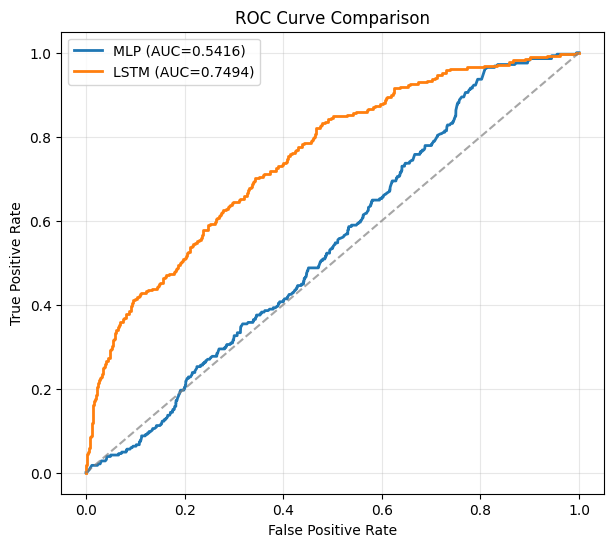

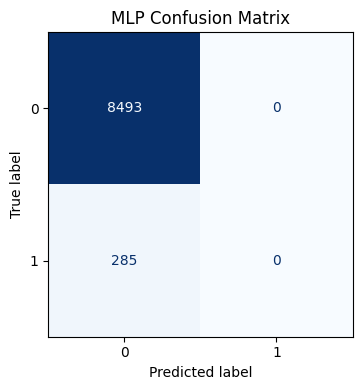

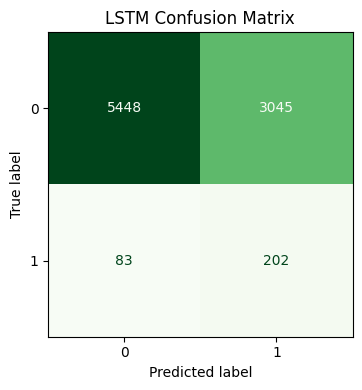

- 추천 모델: LSTM
- LSTM은 MLP보다 Recall +0.7088, F1 +0.1144, ROC-AUC +0.2078 차이를 보입니다.
- MLP는 위험 고객을 거의 예측하지 못해 시계열 변화 반영이 부족한 것으로 볼 수 있습니다.
- 위험 고객 탐지가 중요하므로 Accuracy보다 Recall, F1, ROC-AUC를 우선해서 해석하는 것이 적절합니다.


In [4]:
# 실행
features, metadata, x_seq, y, mlp_bundle, lstm_model = load_data()
x_mlp_test, x_lstm_test, y_test = prepare_test_sets(features, metadata, x_seq, y)

mlp_prob = mlp_bundle['model'].predict_proba(x_mlp_test)[:, 1]
lstm_prob = lstm_model.predict(x_lstm_test, verbose=0).ravel()

mlp_metrics = score(y_test, mlp_prob)
lstm_metrics = score(y_test, lstm_prob)

result_df = pd.DataFrame([
    {'model': 'MLP', **{k: v for k, v in mlp_metrics.items() if k not in ['confusion_matrix', 'fpr', 'tpr']}},
    {'model': 'LSTM', **{k: v for k, v in lstm_metrics.items() if k not in ['confusion_matrix', 'fpr', 'tpr']}},
]).round(4)
result_df.to_csv(RESULT_PATH, index=False)

display(result_df.set_index('model'))

diff_df = result_df.set_index('model').T.copy()
diff_df['LSTM - MLP'] = diff_df['LSTM'] - diff_df['MLP']
display(diff_df)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mlp_metrics['fpr'], mlp_metrics['tpr'], label=f"MLP (AUC={mlp_metrics['roc_auc']:.4f})", linewidth=2)
ax.plot(lstm_metrics['fpr'], lstm_metrics['tpr'], label=f"LSTM (AUC={lstm_metrics['roc_auc']:.4f})", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7)
ax.set_title('ROC Curve Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(mlp_metrics['confusion_matrix']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('MLP Confusion Matrix')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(lstm_metrics['confusion_matrix']).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('LSTM Confusion Matrix')
plt.tight_layout()
plt.show()

for line in interpretation(result_df):
    print(f'- {line}')